# Import and Read results

In [1]:
# best models: offline random forest / or combine random forest
import numpy as np
from national.data_refresh.src import utils
import matplotlib as mpl
from national.data_refresh.src import params
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

import os
import joblib
def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None

def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    for conti in ['Asia', 'Africa', 'Europe', 'South America', 'North America', 'Oceania']:
        if f'conti_{conti}' not in data.columns.tolist():
            data[f'conti_{conti}'] = [0]*len(data)
    return data


In [2]:
fb_cols = params.fb_vars
bg_cols = params.bg_cols
model_specs = {'online': fb_cols+['conti'], 'offline': bg_cols, 'combined': fb_cols + bg_cols}


# plot - pred vs true on fitted data on all models and all indicators using the best model on all data


In [3]:
# read data and set up the plot

df_res = pd.DataFrame()

for indicator in ['internet', 'mobile']:


    for outcome_var in ['wom', 'men', 'ggi']:

        data_path = params.dropbox_data_path / f"combined_data/{indicator}"
        dataset = "combined_multiple_years_no_missing_fb_aligned.csv"
        df = pd.read_csv(data_path / dataset)
        df = df.dropna(subset=params.bg_cols+params.fb_vars)
        df_to_predict = df.loc[df[f'{indicator}_{outcome_var}'].notnull()]

        model_filename = f'{indicator}_combined_{indicator}_{outcome_var}_full_model.pkl'
        model_filepath = params.dropbox_data_path.parent / 'models/rf' / model_filename

        # load the model
        model = load_model(model_filepath)
        df_predict_results = pd.DataFrame(columns=['outcome_var','model_type','iso3', 'year', 'true', 'pred'])

        X = preprocess_data(df_to_predict[model_specs['combined']])
        countries = df_to_predict['iso3'].tolist()
        years = df_to_predict[f'{indicator}_year'].tolist()
        true_values = df_to_predict[f'{indicator}_{outcome_var}'].tolist()
        y_pred = model.predict(X)

        for ind in range(len(y_pred)):
            df_predict_results.loc[len(df_predict_results), :] = [f'{indicator}_{outcome_var}','combined',countries[ind], years[ind], true_values[ind], y_pred[ind]]

        df_res = pd.concat([df_res, df_predict_results], axis=0)

    # df_res.drop(columns=['year'], inplace=True)
    # df_res.rename(columns={f'{indicator}_year': 'year'}, inplace=True)

# Plot the distribution of the differences
years = sorted(df_res['year'].unique())
palette = sns.color_palette("mako", len(years))
#colors = params.colors
#year_color_map = {year:colors for year,colors in zip(years,colors.values())}
year_color_map = dict(zip(years, palette))

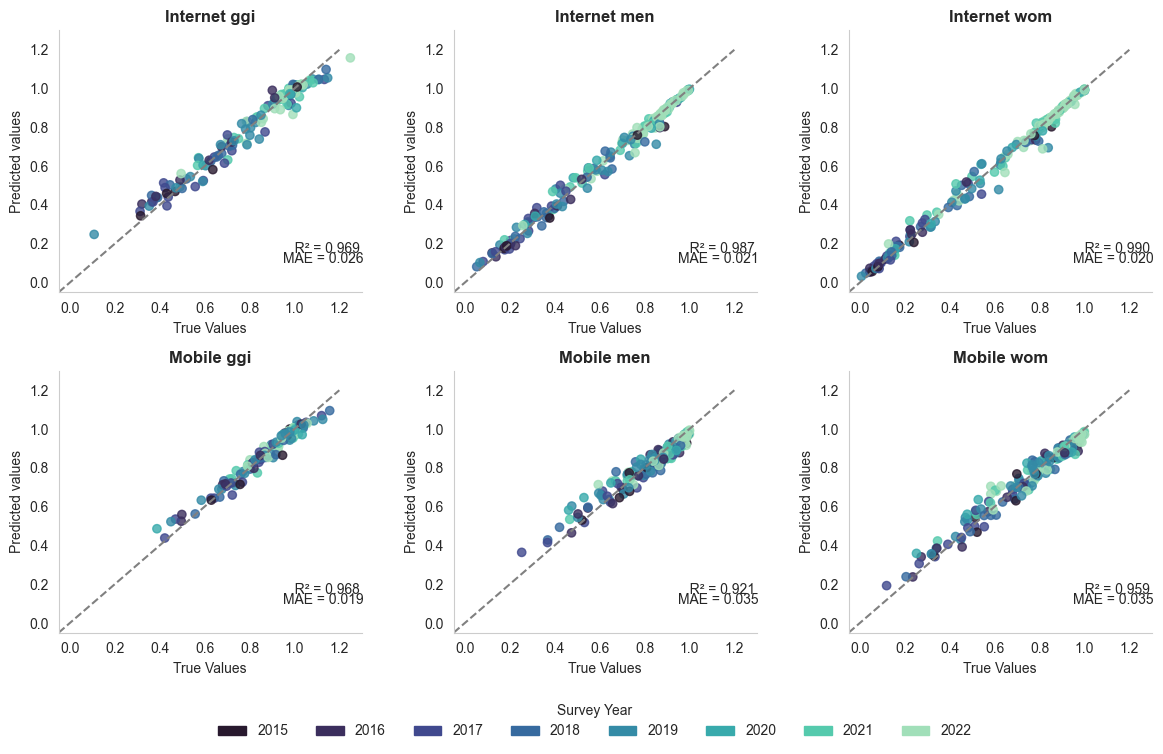

In [5]:
from sklearn.metrics import r2_score, mean_absolute_error
x_min = -0.05
y_max = 1.3
fig, axs = plt.subplots(2, 3, figsize=(12, 8))  # 2 rows for 'internet' and 'mobile', 3 columns for 'ggi', 'men', 'wom'
for row, indicator in enumerate(['internet', 'mobile']):

    for i, type in enumerate(['ggi', 'men', 'wom']):
        df_diff = df_res.loc[df_res['outcome_var'] == f'{indicator}_{type}']

        r_2 = r2_score(df_diff['true'], df_diff['pred'])
        MAE = mean_absolute_error(df_diff['true'], df_diff['pred'])

        scatter = axs[row, i].scatter(df_diff['true'], df_diff['pred'], c=df_diff['year'].map(year_color_map), alpha=0.8)

        axs[row, i].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")

        axs[row, i].set_title(f'{indicator.capitalize()} {type}', fontweight='bold')
        axs[row, i].set_xlabel(f'True Values')
        axs[row, i].set_ylabel('Predicted values')
        x_min = -0.05
        y_max = 1.3
        axs[row, i].set_xlim(x_min, y_max)
        axs[row, i].set_ylim(x_min, y_max)

        axs[row, i].text(0.95, 0.15,f'   R² = {r_2:.3f}', fontsize=10)
        axs[row, i].text(0.95, 0.1, f'MAE = {MAE:.3f}', fontsize=10)
        for spine in ['top', 'right']:
            axs[row, i].spines[spine].set_visible(False)
        axs[row, i].grid(axis='both', linestyle='--', alpha=0)
n_cols = len(years)
legend_elements = [mpatches.Patch(color=year_color_map[year], label=str(round(year))) for year in years]

# Add a shared legend for both rows
fig.legend(handles=legend_elements, loc='lower center', ncol=n_cols, title='Survey Year', bbox_to_anchor=(0.5, 0.025), frameon=False)
plt.subplots_adjust(wspace=0.8, hspace=3)
fig.tight_layout(rect=[0, 0.1, 1, 0.97])

# Save the plot as a PDF
# plt.show()

# plt.savefig(params.dropbox_data_path.parent / 'graphs/pred_vs_true_combined_full_model.pdf')

# predicting on all data from the best model and aligned data


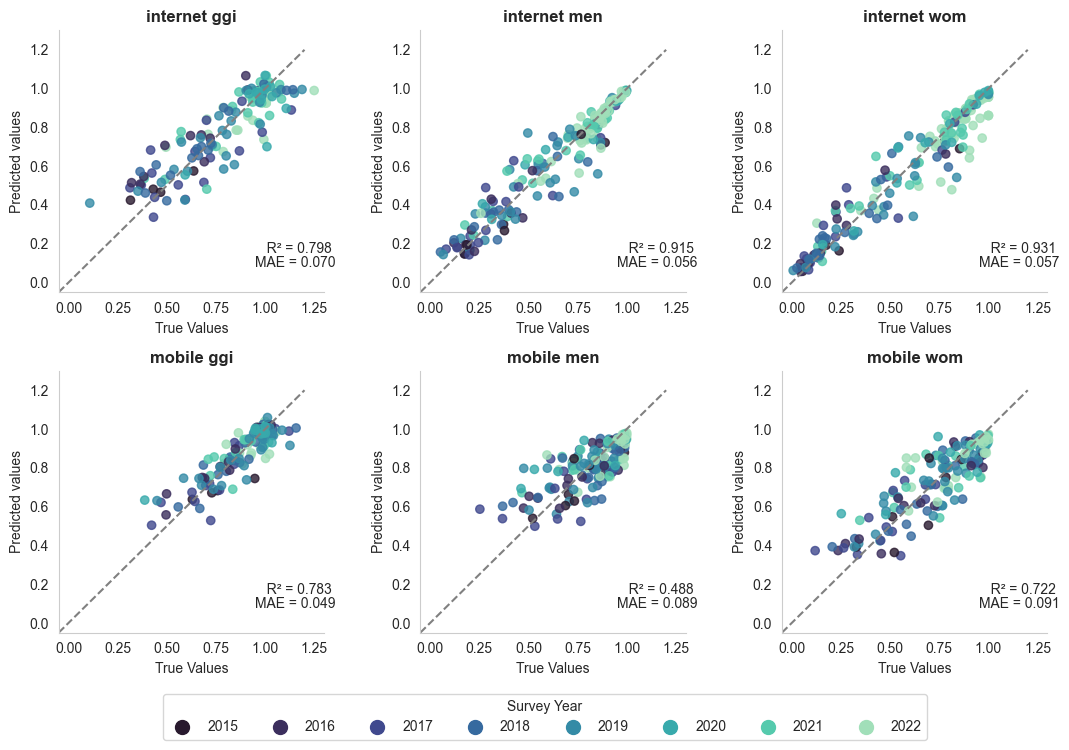

In [10]:
def load_model(file_path):
    return joblib.load(file_path) if os.path.exists(file_path) else None

def preprocess_data(data):
    non_numeric_cols = data.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        data = pd.get_dummies(data, columns=non_numeric_cols)
    for conti in ['Asia', 'Africa', 'Europe', 'South America', 'North America', 'Oceania']:
        if f'conti_{conti}' not in data.columns.tolist():
            data[f'conti_{conti}'] = [0]*len(data)
    return data

# all results are from random forest models
best_model_dict = {"internet": {"men":["combined",'loco'],
                                "wom":["combined",'loyo'],
                                "ggi":["combined",'loyo']},
                   "mobile":   {"men":["combined",'loco'],
                                "wom":["combined",'loco'],
                                "ggi":["combined",'loyo']}}
# ===================================================================
# 1. read results
# =================

def read_result(indicator, outcome_var):

    best_model, measure = best_model_dict[indicator][outcome_var]

    result_path = params.dropbox_data_path.parent / f'files/logs/random_forest_{measure}_results.csv'
    df_res = pd.read_csv(result_path)
    df_res = df_res[(df_res['outcome_var']==f'{indicator}_{outcome_var}')& (df_res['model_type']==best_model)]

    # merge the country back?????
    df = pd.read_csv(params.dropbox_data_path / f"combined_data/{indicator}/combined_multiple_years_no_missing_fb_aligned.csv" )
    df = df.dropna(subset=[f'{indicator}_{outcome_var}'])
    if measure == 'loyo':
        df_res = pd.merge(df_res,df[['iso3',f'{indicator}_year',f'{indicator}_{outcome_var}']],
                           left_on=['year','true'],right_on=[f'{indicator}_year',f'{indicator}_{outcome_var}'],
                           how='left')
        """
        # checking whether the merge is correct
        for ind,row in df_res[['true','year']].iterrows():
            true, year = row['true'],row['year']
            print(len(df.loc[(df[f'{indicator}_year']==year)& (df[f'{indicator}_{outcome_var}']==true)]))

        """
    else:

        df_res = pd.merge(df_res,df[['iso3',f'{indicator}_year',f'{indicator}_{outcome_var}','country']],
                          left_on=['true','country'],right_on=[f'{indicator}_{outcome_var}','country'],
                            how='left')
    return df_res
# plot

for indicator in ['internet', 'mobile']:
    df_res = pd.DataFrame()

    for outcome_var in ['wom', 'men', 'ggi']:
        temp = read_result(indicator, outcome_var)
        df_res = pd.concat([df_res, temp], axis=0)

    df_res.drop(columns=['year'], inplace=True)
    df_res.rename(columns={f'{indicator}_year': 'year'}, inplace=True)

# Plot the distribution of the differences
years = sorted(df_res['year'].unique())
palette = sns.color_palette("mako", len(years))
#colors = params.colors
#year_color_map = {year:colors for year,colors in zip(years,colors.values())}

year_color_map = dict(zip(years, palette))

fig, axs = plt.subplots(2, 3, figsize=(11, 8))  # 2 rows for 'internet' and 'mobile', 3 columns for 'ggi', 'men', 'wom'
for row, indicator in enumerate(['internet', 'mobile']):
    df_res = pd.DataFrame()
    for outcome_var in ['wom', 'men', 'ggi']:
        temp = read_result(indicator, outcome_var)
        df_res = pd.concat([df_res, temp], axis=0)

    df_res.drop(columns=['year'], inplace=True)
    df_res.rename(columns={f'{indicator}_year': 'year'}, inplace=True)

    for i, type in enumerate(['ggi', 'men', 'wom']):
        df_diff = df_res.loc[df_res['outcome_var'] == f'{indicator}_{type}']

        r_2 = np.corrcoef(df_diff['true'], df_diff['pred'])[0, 1] ** 2
        MAE = np.mean(np.abs(df_diff['true'] - df_diff['pred']))

        scatter = axs[row, i].scatter(df_diff['true'], df_diff['pred'], c=df_diff['year'].map(year_color_map), alpha=0.8)

        axs[row, i].set_title(f'{indicator} {type}', fontweight='bold')
        axs[row, i].set_xlabel(f'True Values')
        axs[row, i].set_ylabel('Predicted values')
        x_min = -0.05
        y_max = 1.3
        axs[row, i].plot([x_min, 1.2], [x_min, 1.2], ls="--", c="grey")
        axs[row, i].set_xlim(x_min, y_max)
        axs[row, i].set_ylim(x_min, y_max)

        axs[row, i].text(0.95, 0.15,f'   R² = {r_2:.3f}', fontsize=10)
        axs[row, i].text(0.95, 0.08, f'MAE = {MAE:.3f}', fontsize=10)
        for spine in ['top', 'right']:
            axs[row, i].spines[spine].set_visible(False)
        axs[row, i].grid(axis='both', linestyle='--', alpha=0)

n_cols = len(years)
import matplotlib.lines as mlines

# Define the legend with dots instead of rectangles
legend_elements = [mlines.Line2D([], [], color=year_color_map[year], marker='o', linestyle='None', markersize=10, label=str(round(year))) for year in years]

# Add the shared legend for both rows
fig.legend(handles=legend_elements, loc='lower center', ncol=n_cols, title='Survey Year', bbox_to_anchor=(0.5, 0.03), frameon=True)

plt.subplots_adjust(wspace=0.8, hspace=3)
fig.tight_layout(rect=[0, 0.1, 1, 0.97])

# Save the plot as a PDF
# plt.show()

plt.savefig(params.dropbox_data_path.parent / 'graphs/pred_vs_true_combined.pdf')

In [25]:
# 3.2 remove countries in sanction list
sanction_list = ['IRN','PRK','SYR','CUB','SDN','RUS','VEN','ZWE','CHN']
df_all_res = df_res[~df_res['iso3'].isin(sanction_list)].copy()
df_all_res[['pred','true']] = df_all_res[['pred', 'true']].astype(float)


## produce the map of the prediction with the aligned data, best models


/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_1619/1288885619.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_1619/1288885619.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 1, 0.99])
/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_1619/1288885619.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.01, 1, 0.99])


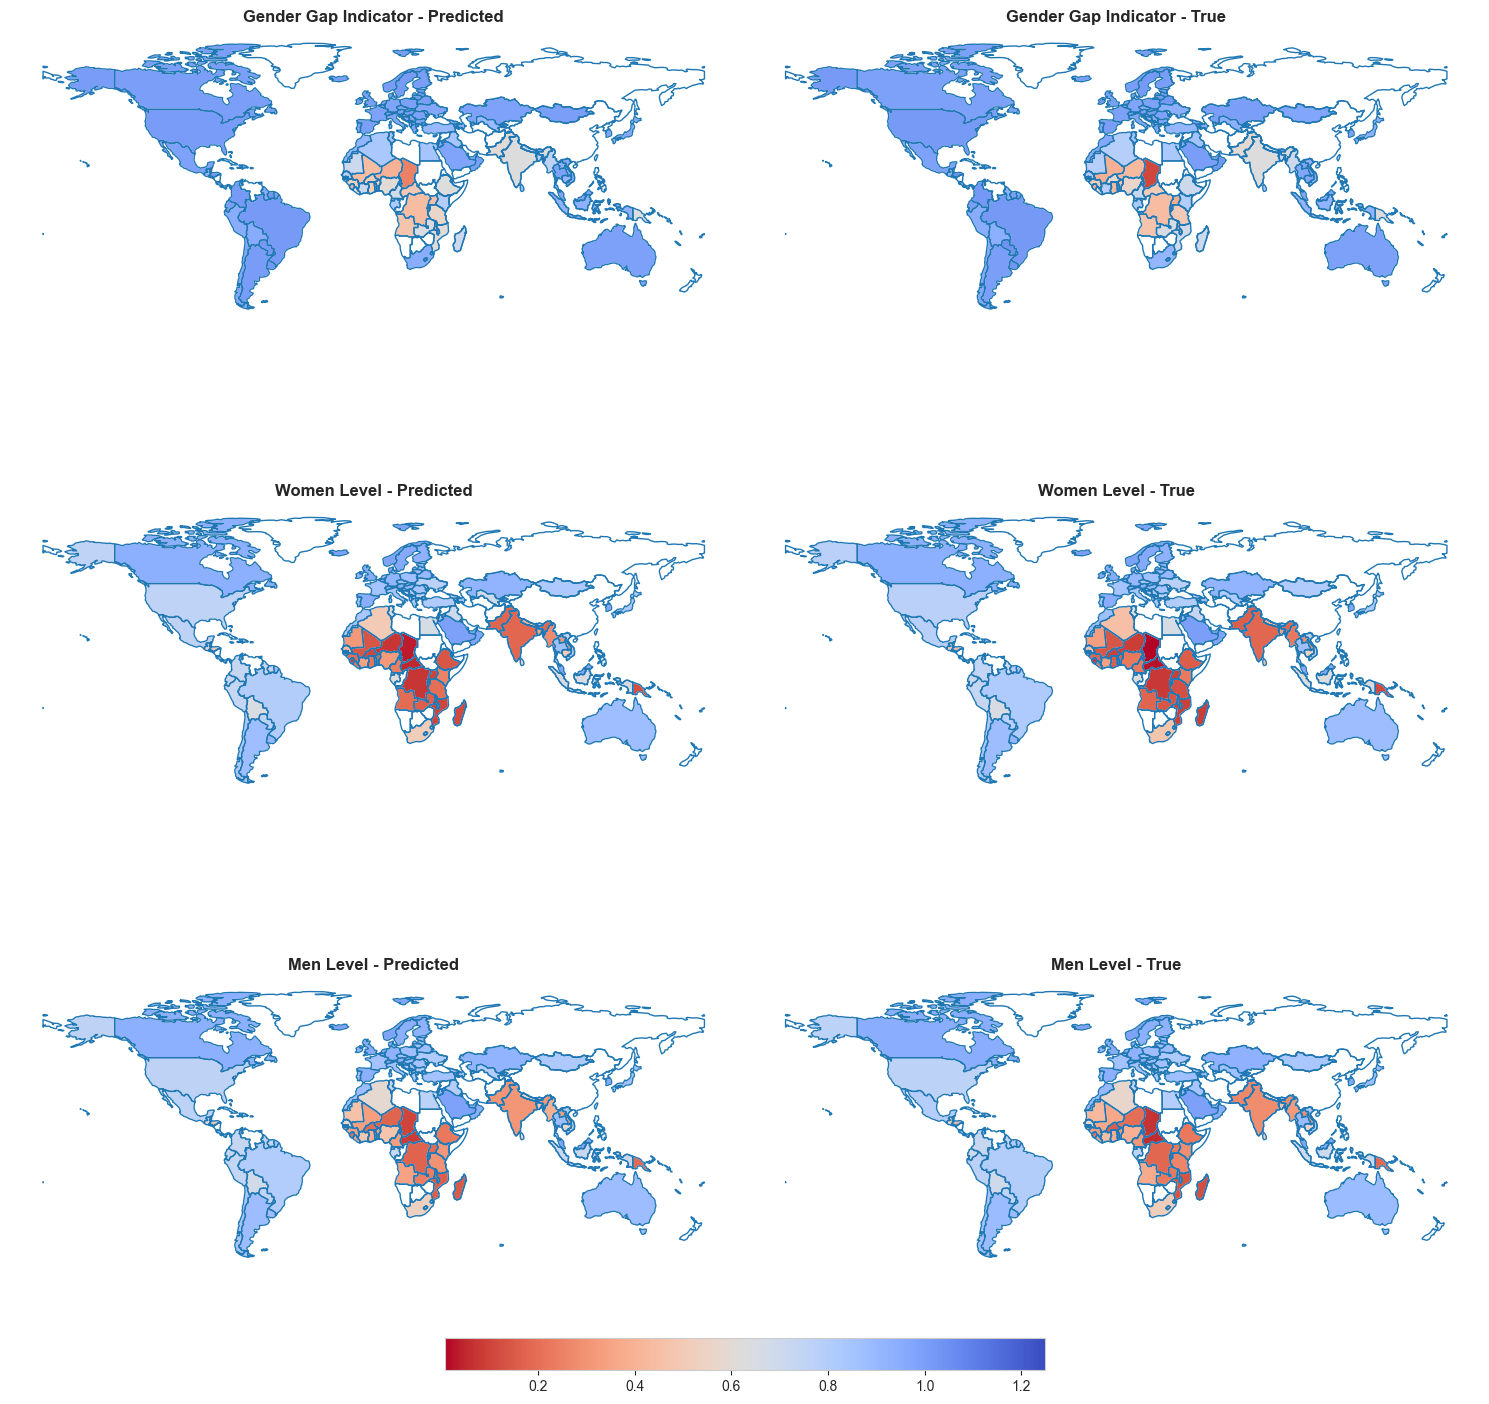

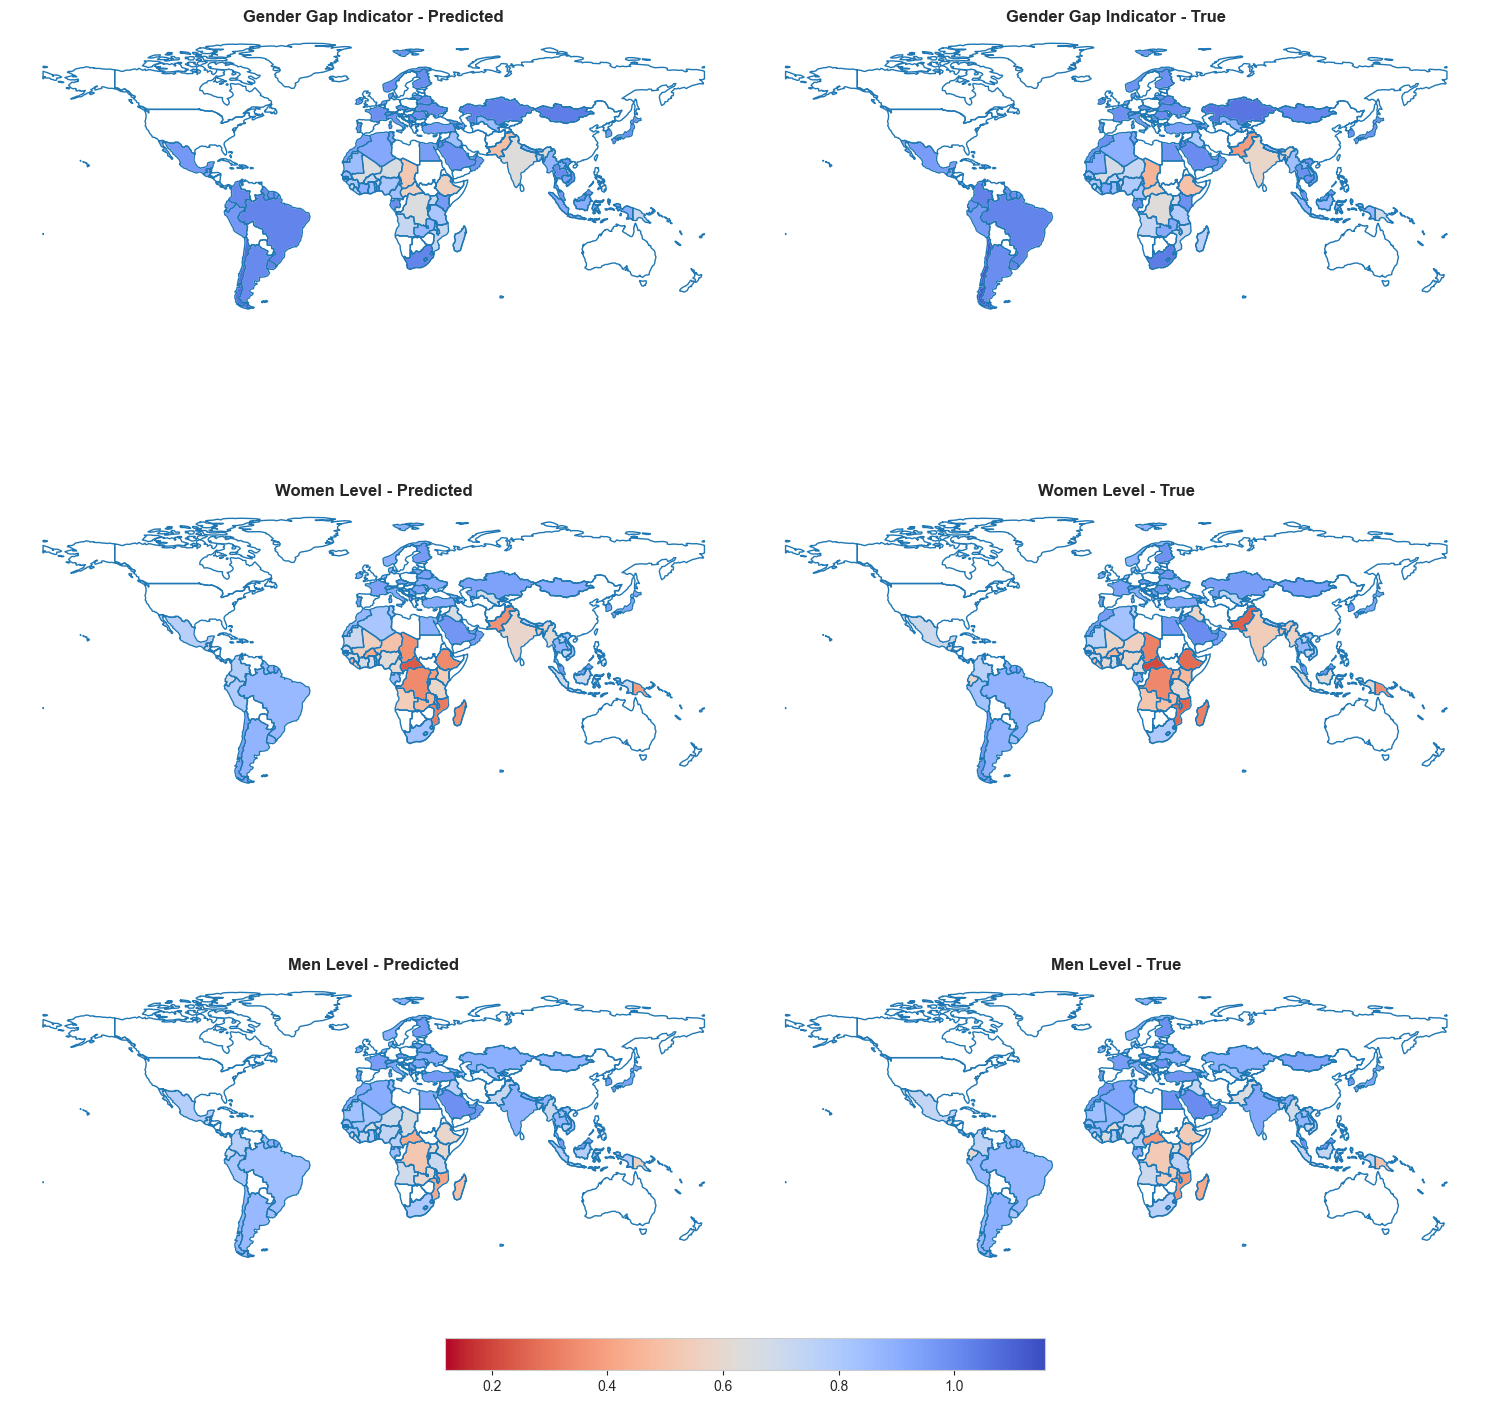

In [26]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

outcome_var_dict = {'ggi': 'Gender Gap Indicator','wom':'Women Level','men':'Men Level'}
outcome_vars = ['ggi','wom','men']

for indicator in ['internet','mobile']:
    # Create the figure with 6 subplots (3 rows, 2 columns)
    fig, axs = plt.subplots(3, 2, figsize=(15, 16))
    axs = axs.flatten()

    # Define the minimum and maximum values for the color scale
    vmin = min(df_all_res.loc[df_all_res['outcome_var'].str.contains(indicator),'true'].min(), df_all_res.loc[df_all_res['outcome_var'].str.contains(indicator),'pred'].min())
    vmax = max(df_all_res.loc[df_all_res['outcome_var'].str.contains(indicator),'true'].max(), df_all_res.loc[df_all_res['outcome_var'].str.contains(indicator),'pred'].max())

    # Define the colormap
    cmap = 'coolwarm_r'

    # Loop over outcome variables and plot both predicted and true values
    for i, outcome_var in enumerate(outcome_vars):
        # Filter data for current outcome_var
        df_res = df_all_res[df_all_res['outcome_var'] == f'{indicator}_{outcome_var}']

        # Merge predicted values with world map
        world_pred = world.merge(df_res[['iso3', 'pred']], left_on='iso_a3', right_on='iso3', how='left')

        # Plot predicted values on the left side (first column)
        world_pred.boundary.plot(ax=axs[2 * i], linewidth=1)
        world_pred.plot(column='pred', ax=axs[2 * i], cmap=cmap, missing_kwds={"color": "white"},
                        vmin=vmin, vmax=vmax)
        axs[2 * i].set_title(f'{outcome_var_dict[outcome_var]} - Predicted',fontweight='bold')
        axs[2 * i].axis('off')

        # Merge true values with world map
        world_true = world.merge(df_res[['iso3', 'true']], left_on='iso_a3', right_on='iso3', how='left')

        # Plot true values on the right side (second column)
        world_true.boundary.plot(ax=axs[2 * i + 1], linewidth=1)
        world_true.plot(column='true', ax=axs[2 * i + 1], cmap=cmap, missing_kwds={"color": "white"},
                        vmin=vmin, vmax=vmax)
        axs[2 * i + 1].set_title(f'{outcome_var_dict[outcome_var]} - True',fontweight='bold')
        axs[2 * i + 1].axis('off')

    # Create a single colorbar at the center bottom of the figure
    # Adjust the spacing between subplots

    # Create a single colorbar at the center bottom of the figure
    cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])  # Position: [left, bottom, width, height]
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    # Add the colorbar
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

    # Adjust layout to ensure padding
    plt.subplots_adjust(wspace=0.1, hspace=0.15)  # Increase horizontal and vertical space between plots
    # fig.suptitle(f'{indicator.capitalize()}  Predicted vs True Values', fontsize=16, fontweight='bold', y=0.95)

    plt.tight_layout(rect=[0, 0.01, 1, 0.99])

    # Show the plot
    # plt.show()
    # plt.savefig(params.dropbox_data_path.parent / f'graphs/{indicator}_pred_vs_true_map.pdf')


# predicting on all data from the best model with yearly data


## produce the result predicted from year 2015-2024

In [ ]:
# don't need to re-execute if the result files are already there
for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
    for indicator in ['internet', 'mobile']:
        for outcome_var in ['ggi','wom','men']:
    
            df_res = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year', 'true', 'pred'])
    
            for year in range(2015, 2025):
    
                df_model = pd.read_csv(params.dropbox_data_path / f'combined_data/{indicator}/year_align/combined_multiple_years_no_missing_fb_aligned_{round(year)}.csv')
    
                df_model = df_model.dropna(subset=params.bg_cols+params.fb_vars)
    
                model_filename = f'{indicator}_combined_{outcome_var}_{indicator}_{outcome_var}_full_model.pkl'
                model_filepath = params.dropbox_data_path.parent / f'models/{model_folder}' / model_filename
    
                # load the model
    
                temp = pd.DataFrame(columns=['indicator','outcome_var','model_type','iso3', 'year', 'true', 'pred'])
    
                model = load_model(model_filepath)
                countries = df_model['iso3'].tolist()
                X = preprocess_data(df_model[model_specs['combined']])
                X = X[model.feature_names_in_]
                y_pred = model.predict(X)
    
                for ind in range(len(y_pred)):
                    true_value = df_model.loc[(df_model[f'{indicator}_year']==year) & (df_model[f'iso3']==countries[ind]), f'{indicator}_{outcome_var}']
                    true_value = true_value.values[0] if len(true_value) > 0 else None
                    temp.loc[len(temp), :] = [indicator,outcome_var,'combined',countries[ind], year, true_value, y_pred[ind]]
    
                temp = temp.groupby(['indicator','outcome_var','model_type','iso3'], as_index=False).mean() # some countries have multiple entries but the results are the same
    
                df_res = pd.concat([df_res, temp], axis=0)
    
            df_res.to_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/{indicator}_{outcome_var}.csv', index=False)
    


# map on the 2024 data and predicted values

In [3]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
world = world[(world.pop_est > 0) & (world.name != "Antarctica")]

outcome_var_dict = {'ggi': 'Gender Gap Indicator','wom':'Women Level','men':'Men Level'}
outcome_vars = ['ggi','wom','men']

df_all_res = pd.DataFrame()
for indicator in ['internet','mobile']:
    for outcome_var in ['ggi','wom','men']:
        temp  = pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/{indicator}_{outcome_var}.csv')
        df_all_res = pd.concat([df_all_res, temp], axis=0)
# select the 2024 data
df_all_res = df_all_res[df_all_res['year']==2024]

# remove countries in sanction list
sanction_list = ['IRN','PRK','SYR','CUB','SDN','RUS','VEN','ZWE','CHN']
df_all_res = df_all_res[~df_all_res['iso3'].isin(sanction_list)].copy()
df_all_res[['pred','true']] = df_all_res[['pred', 'true']].astype(float)


/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_1353/2188594295.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [75]:

# Create the figure with 6 subplots (3 rows, 2 columns)
fig, axs = plt.subplots(3, 2, figsize=(15, 16))
axs = axs.flatten()

# Define the minimum and maximum values for the color scale
vmin  = df_all_res['pred'].min()
vmax = df_all_res['pred'].max()

# Define the colormap
cmap = 'coolwarm_r'
left_panel = 'internet'
right_panel = 'mobile'

# Loop over outcome variables and plot both predicted and true values
for i, outcome_var in enumerate(outcome_vars):

    # Filter data for current outcome_var
    df_res = df_all_res[df_all_res['outcome_var'] == outcome_var]

    # Merge predicted values with world map
    world_lft = world.merge(df_res.loc[df_res['indicator']==left_panel, ['iso3', 'pred']], left_on='iso_a3', right_on='iso3', how='left')

    # Plot predicted values on the left side (first column)
    world_lft.boundary.plot(ax=axs[2 * i], linewidth=1)
    world_lft.plot(column='pred', ax=axs[2 * i], cmap=cmap, missing_kwds={"color": "white"},
                    vmin=vmin, vmax=vmax)
    axs[2 * i].set_title(f'{outcome_var_dict[outcome_var]} - {left_panel.capitalize()}',fontweight='bold')
    axs[2 * i].axis('off')


    world_true = world.merge(df_res.loc[df_res['indicator']==right_panel, ['iso3', 'pred']], left_on='iso_a3', right_on='iso3', how='left')
    # Plot true values on the right side (second column)
    world_true.boundary.plot(ax=axs[2 * i + 1], linewidth=1)
    world_true.plot(column='pred', ax=axs[2 * i + 1], cmap=cmap, missing_kwds={"color": "white"},
                    vmin=vmin, vmax=vmax)
    axs[2 * i + 1].set_title(f'{outcome_var_dict[outcome_var]} -  {right_panel.capitalize()}',fontweight='bold')
    axs[2 * i + 1].axis('off')

# Create a single colorbar at the center bottom of the figure
# Adjust the spacing between subplots

# Create a single colorbar at the center bottom of the figure
cbar_ax = fig.add_axes([0.3, 0.05, 0.4, 0.02])  # Position: [left, bottom, width, height]
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Add the colorbar
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')

# Adjust layout to ensure padding
plt.subplots_adjust(wspace=0.1, hspace=0.15)  # Increase horizontal and vertical space between plots
# fig.suptitle(f'{indicator.capitalize()}  Predicted vs True Values', fontsize=16, fontweight='bold', y=0.95)

plt.tight_layout(rect=[0, 0.01, 1, 0.99])

# Show the plot
# plt.show()
plt.savefig(params.dropbox_data_path.parent / f'graphs/map_of_predicted_2024_values.pdf')


/var/folders/04/q8s7l0r939g8fqqljjn3_rbm0000gn/T/ipykernel_13999/2188594295.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))



## visualise the results of ggi by trends and developed type

In [ ]:

indicator = 'mobile'
model_folder = '18_plus_paired_levels'# 'aggregate_paired_levels'
for model_folder in ['18_plus_paired_levels','aggregate_paired_levels','18_plus','aggregate','rf','paired_levels']:
    df_res = pd.read_csv(params.dropbox_data_path.parent / f'results/pred_by_year_data/{model_folder}/combined/{indicator}_ggi.csv')
    start_year = 2015
    end_year = 2024
    
    df_plot = df_res.pivot(index = 'iso3',columns='year',values=['true','pred']).reset_index()
    df_plot.columns = [f'{x}_{round(y)}' if y != '' else f'{x}' for x,y in df_plot.columns]
    
    
    # label gap types and region names 
    
    threshold = 0.05  #  within 0.05 change is considered stable
    income_year = 2022
    
    # Calculate the difference between start year and end year predictions
    df_plot['gap_diff'] = df_plot[f'pred_{end_year}'] - df_plot[f'pred_{start_year}']
    
    # Classify the gap_type based on the threshold
    df_plot['gap_type'] = df_plot['gap_diff'].apply(
        lambda x: 'closing' if round(x,3) > threshold else
                  'widening' if round(x,3) < -threshold else
                  'stable (minor change)' )
    
    df_plot['continent'] = [utils.get_continent_from_iso3(iso3) for iso3 in df_plot['iso3']]
    
    # income type
    df_income_level = pd.read_csv(params.dropbox_data_path.parent / 'files/income_classification.csv')
    df_income_level.columns = df_income_level.loc[4,:].values
    
    rows_to_remove = range(0,10)
    df_income_level.drop(rows_to_remove, inplace=True)
    df_income_level.replace('..', None, inplace=True)
    df_income_level.rename(columns = {'Data for calendar year':'country',np.nan:'iso3' },inplace=True)
    df_income_level.loc[df_income_level['iso3']=='VEN',f'{income_year}'] = 'UM'
    df_plot = df_plot.merge(df_income_level[['iso3', f'{income_year}']],on='iso3',how='left')
    
    # sub-region
    df_sub_region = pd.read_csv(params.dropbox_data_path.parent / 'files/definition_of_regions.csv',delimiter=';')
    df_plot = df_plot.merge(df_sub_region[['ISO-alpha3 Code','Sub-region Name']],left_on='iso3',right_on='ISO-alpha3 Code',how='left')
    df_plot.rename(columns = {'Sub-region Name':'sub_region'},inplace=True)
    
    
    # initiating the plot
    years = range(start_year, end_year + 1)
    
    # Get unique values for continents and gap_types
    continents = df_plot['continent'].unique()
    gap_types = df_plot['gap_type'].unique()
    
    income_dict = {'H':'High Income','UM':'Upper Middle Income','LM':'Lower Middle Income','L':'Low Income'}
    income_types = income_dict.keys()
    
    ind_1 = f'{income_year}'
    ind_2 = 'gap_type'
    
    # Create a color map for continents
    colors = plt.get_cmap('tab20', len(continents))  # Use a colormap with unique colors
    continent_color_map = {continent: colors(i) for i, continent in enumerate(continents)}
    
    # Define the number of rows and columns for the subplots grid
    n_rows = len(df_plot[ind_1].unique())  # Rows by income groups
    n_cols = len(gap_types)  # Columns by gap_type
    
    
    import matplotlib.pyplot as plt
    
    # Define the years for plotting
    years = range(start_year, end_year + 1)
    color_map = 'tab10'
    # Combine South and North America into "Americas"
    df_plot['continent'] = df_plot['continent'].replace({'South America': 'Americas', 'North America': 'Americas'})
    
    # Define colors for continents and income types
    colors = plt.get_cmap(color_map, len(df_plot['continent'].unique()))
    continent_color_map = {continent: colors(i) for i, continent in enumerate(df_plot['continent'].unique())}
    
    income_dict = {'H': 'High Income', 'UM': 'Upper Middle Income', 'LM': 'Lower Middle Income', 'L': 'Low Income'}
    income_types = list(income_dict.keys())
    income_colors = plt.get_cmap(color_map, len(income_types))
    income_map = {income_type: income_colors(i) for i, income_type in enumerate(income_types)}
    
    # Define a colormap for sub-regions (used for Asia and Africa)
    subregion_colors = plt.get_cmap(color_map, len(df_plot['sub_region'].unique()))
    subregion_color_map = {sub_region: subregion_colors(i) for i, sub_region in enumerate(df_plot['sub_region'].unique())}
    
    # Create a figure with 4 subplots in one row
    fig, axs = plt.subplots(2,2, figsize=(10, 8))
    axs = axs.flatten()
    # Panel 1: Median trend by geographic region (Continent)
    ax1 = axs[1]
    for continent, continent_group in df_plot.groupby('continent'):
        for country, country_group in continent_group.groupby('iso3'):
            pred_values = country_group[[f'pred_{year}' for year in years]].values.flatten()
            ax1.plot(years, pred_values, color='grey', alpha=0.08)
    
        # Calculate the median predicted values for each continent
        median_values = continent_group[[f'pred_{year}' for year in years]].median().values
        color = continent_color_map[continent]
        ax1.plot(years, median_values, label=continent, color=color, linewidth=2, alpha=1)
    
    ax1.set_title('Median Trend by Geographic Region', fontweight='bold')
    ax1.set_xlabel('Year', fontweight='bold')
    ax1.legend(loc='lower center', title='Region', frameon=False, ncol=3, bbox_to_anchor=(0.5, -0.6
                                                                                          ))
    
    # Panel 2: Median trend by country income classification
    ax2 = axs[0]
    for income_type, income_group in df_plot.groupby(f'{income_year}'):
        for country, country_group in income_group.groupby('iso3'):
            pred_values = country_group[[f'pred_{year}' for year in years]].values.flatten()
            ax2.plot(years, pred_values, color='grey', alpha=0.08)
    
        # Calculate the median predicted values for each income group
        median_values = income_group[[f'pred_{year}' for year in years]].median().values
        color = income_map[income_type]
        ax2.plot(years, median_values, label=income_dict[income_type], color=color, linewidth=2, alpha=1)
    
    ax2.set_title('Median Trend by Income Classification', fontweight='bold')
    ax2.set_xlabel('Year', fontweight='bold')
    ax2.legend(loc='lower center', title='Income Classification', frameon=False, ncol=2, bbox_to_anchor=(0.5, -0.55))
    
    # Panel 3: Subplot for Asia
    ax3 = axs[2]
    asia_group = df_plot[df_plot['continent'] == 'Asia']
    for sub_region, sub_region_group in asia_group.groupby('sub_region'):
        for country, country_group in sub_region_group.groupby('iso3'):
            ax3.plot(years, country_group[[f'pred_{year}' for year in years]].values.flatten(), color='grey', alpha=0.1)
        color = subregion_color_map[sub_region]
        ax3.plot(years, sub_region_group[[f'pred_{year}' for year in years]].median().values, label=sub_region, color=color, linewidth=2)
    ax3.set_title('Median Trend in Asia', fontweight='bold')
    ax3.set_xlabel('Year', fontweight='bold')
    ax3.legend(title='Sub Region', loc='lower center', frameon=False, ncol=3, bbox_to_anchor=(0.5, -0.55))
    
    # Panel 4: Subplot for Africa
    ax4 = axs[3]
    africa_group = df_plot[df_plot['continent'] == 'Africa']
    for sub_region, sub_region_group in africa_group.groupby('sub_region'):
        for country, country_group in sub_region_group.groupby('iso3'):
            ax4.plot(years, country_group[[f'pred_{year}' for year in years]].values.flatten(), color='grey', alpha=0.1)
        color = subregion_color_map[sub_region]
        ax4.plot(years, sub_region_group[[f'pred_{year}' for year in years]].median().values, label=sub_region, color=color, linewidth=2)
    ax4.set_title('Median Trend in Africa', fontweight='bold')
    ax4.set_xlabel('Year', fontweight='bold')
    
    ax4.legend(title='Sub Region', loc='lower center', frameon=False, ncol=3, bbox_to_anchor=(0.5, -0.5))
    
    # Customizing axes, grid, and layout for all subplots
    for ax in axs:
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.set_ylabel(f'Predicted {indicator} gender gap', fontweight='bold')
        ax.grid(axis='both', linestyle='--', alpha=0.3)
        ax.set_ylim(0, 1.2)
    
    # Adjust layout for better spacing between panels
    
    plt.subplots_adjust(wspace=0.2, hspace=0.75)
    # fig.suptitle(f'{indicator.capitalize()} ggi Predicted Trends by Geographic Region', fontsize=16, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 1, 0.99])
    # Show or save the plot
    # plt.show()
    
    plt.savefig(params.dropbox_data_path.parent / f'graphs/predicted_yearly_trends/{model_folder}_combined_{indicator}_ggi_trend.pdf')
